# LB/UB Plot (MIPGap=1e-3)

This notebook loads the three CSV logs and plots LB/UB vs time in three scales: linear, semilogx (log-x), and loglog.

In [11]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Inputs
csv_files = [
    "snog_1e3_TL15_6h.csv",
    "snog_1e3_TL30_6h.csv",
    "snog_1e3_TL60_9h.csv",
]

# Y-axis range control (set to None to disable)
ymin, ymax = 0.975, 0.982

MIPGAP_STR = "1e-3"  # for title

def pick_column(df, want_keys):
    """
    Heuristic column picker: normalizes column names to alnum lowercase and matches any token in want_keys.
    Returns the first column whose numeric conversion is mostly non-NaN.
    """
    for c in df.columns:
        n = "".join(ch for ch in str(c).lower() if ch.isalnum())
        if any(k in n for k in want_keys):
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().mean() > 0.5:
                return c
    raise ValueError(f"Can't find column for {want_keys}. Columns={list(df.columns)}")

def parse_timelimit_from_name(name: str) -> str:
    m = re.search(r"_TL(\d+)_", name)
    return m.group(1) if m else "?"

dfs = []
for fp in csv_files:
    df = pd.read_csv(fp)
    time_col = pick_column(df, ["time", "times", "sec", "seconds"])
    lb_col   = pick_column(df, ["lb", "lowerbound", "dualbound", "zlb"])
    ub_col   = pick_column(df, ["ub", "upperbound", "primalbound", "zub"])
    tl = parse_timelimit_from_name(fp)
    dfs.append({
        "file": fp,
        "TL": tl,
        "df": df,
        "time_col": time_col,
        "lb_col": lb_col,
        "ub_col": ub_col,
    })

[(d["file"], d["time_col"], d["lb_col"], d["ub_col"]) for d in dfs]

[('snog_1e3_TL15_6h.csv', 'Time (s)', 'LB', 'UB'),
 ('snog_1e3_TL30_6h.csv', 'Time (s)', 'LB', 'UB'),
 ('snog_1e3_TL60_9h.csv', 'Time (s)', 'LB', 'UB')]

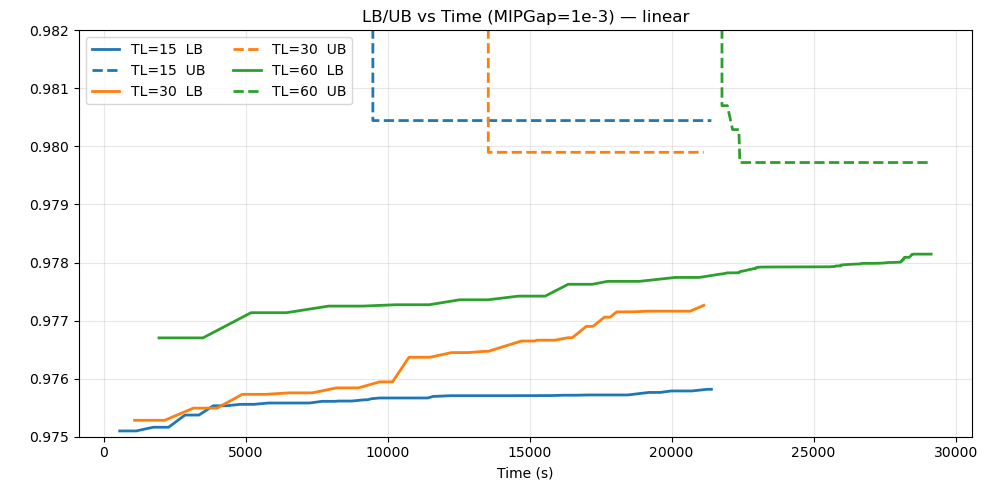

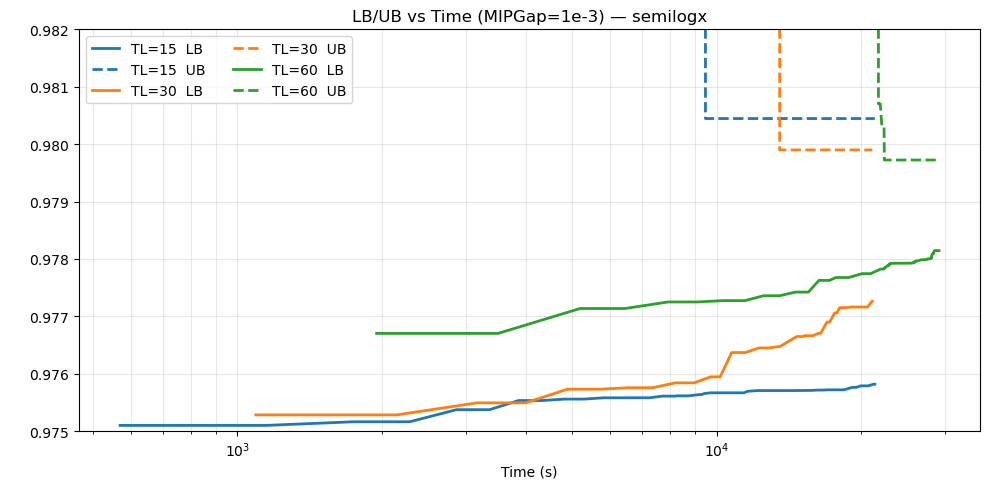

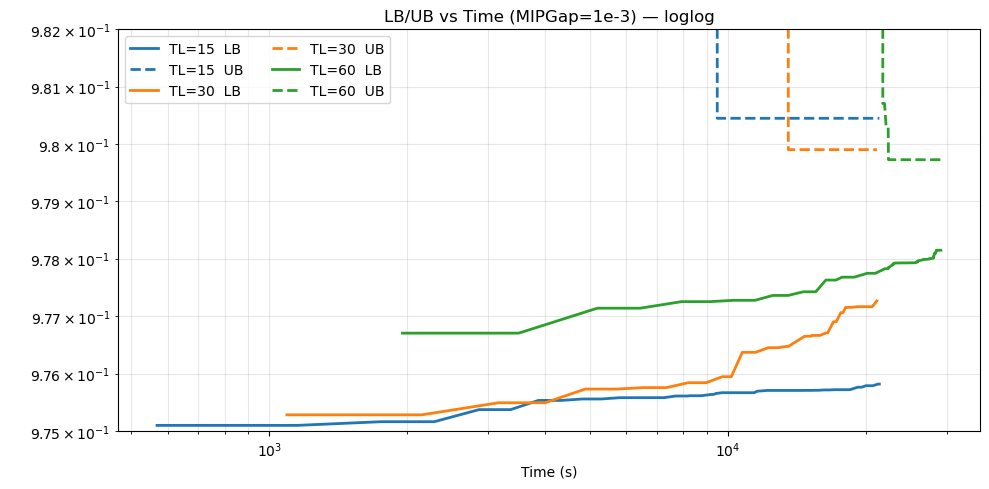

In [12]:
def plot_all(scale: str):
    """
    scale in {"linear","semilogx","loglog"}
    """
    plt.figure(figsize=(10,5))

    # Style: same TL uses same color; LB solid, UB dashed
    tl_to_color = {tl: f"C{i}" for i, tl in enumerate(sorted({d["TL"] for d in dfs}))}

    for d in dfs:
        df = d["df"]
        x = pd.to_numeric(df[d["time_col"]], errors="coerce")
        lb = pd.to_numeric(df[d["lb_col"]], errors="coerce")
        ub = pd.to_numeric(df[d["ub_col"]], errors="coerce")

        # Drop NaNs and keep positive x for log scales
        mask = x.notna() & lb.notna() & ub.notna()
        x, lb, ub = x[mask], lb[mask], ub[mask]

        if scale in {"semilogx", "loglog"}:
            pos = x > 0
            x, lb, ub = x[pos], lb[pos], ub[pos]
        if scale == "loglog":
            posy = (lb > 0) & (ub > 0)
            x, lb, ub = x[posy], lb[posy], ub[posy]

        tl = d["TL"]
        color = tl_to_color.get(tl, None)

        if scale == "linear":
            plt.plot(x, lb, linestyle="-",  linewidth=2.0, color=color, label=f"TL={tl}  LB")
            plt.plot(x, ub, linestyle="--", linewidth=2.0, color=color, label=f"TL={tl}  UB")
        elif scale == "semilogx":
            plt.semilogx(x, lb, linestyle="-",  linewidth=2.0, color=color, label=f"TL={tl}  LB")
            plt.semilogx(x, ub, linestyle="--", linewidth=2.0, color=color, label=f"TL={tl}  UB")
        elif scale == "loglog":
            plt.loglog(x, lb, linestyle="-",  linewidth=2.0, color=color, label=f"TL={tl}  LB")
            plt.loglog(x, ub, linestyle="--", linewidth=2.0, color=color, label=f"TL={tl}  UB")
        else:
            raise ValueError("scale must be one of: linear, semilogx, loglog")

    plt.xlabel("Time (s)")
    plt.ylabel(" ")
    plt.title(f"LB/UB vs Time (MIPGap={MIPGAP_STR}) — {scale}")

    # Apply y-axis limits if provided
    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)

    plt.legend(ncol=2)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_all("linear")
plot_all("semilogx")
plot_all("loglog")
